<!-- colab-badge -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ami-null/python-course/blob/main/14_plotting-with-seaborn.ipynb)

# Plotting with Seaborn

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_theme()
# sns.set_context("paper")
# sns.set_style("whitegrid")
df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


(160.0, 240.0)

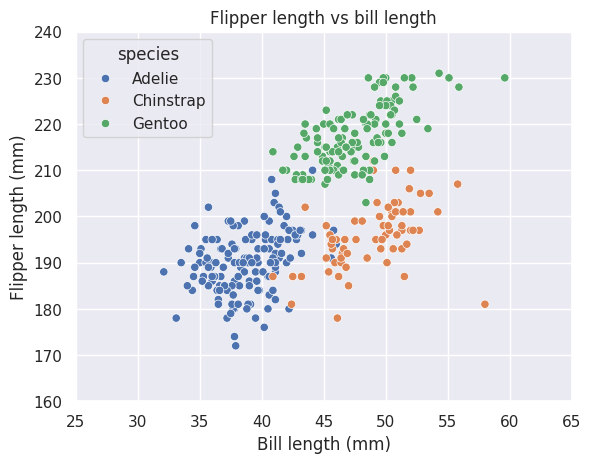

In [3]:
sns.scatterplot(
    data = df,
    x = "bill_length_mm",
    y = "flipper_length_mm",
    hue = "species"
)
plt.title("Flipper length vs bill length")
plt.xlabel("Bill length (mm)")
plt.ylabel("Flipper length (mm)")
plt.xlim([25,65])
plt.ylim([160, 240])

<Axes: xlabel='island', ylabel='count'>

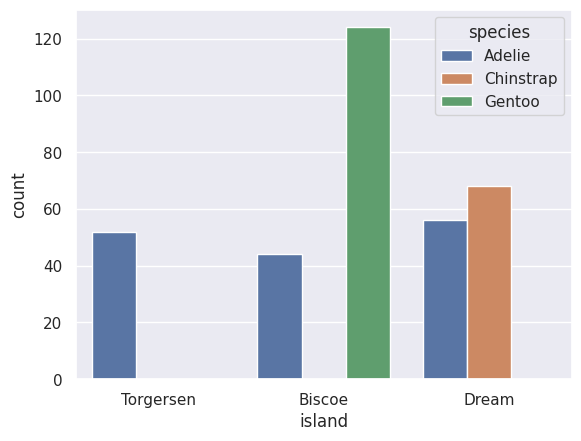

In [4]:
sns.countplot(
    data = df,
    x = "island",
    hue = "species"
)    # seaborn finds the frequencies automatically

<Axes: xlabel='island', ylabel='body_mass_g'>

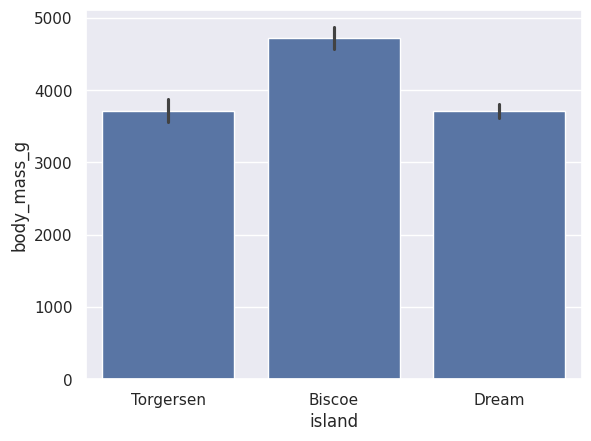

In [5]:
sns.barplot(
    data = df,
    x = "island",
    y = "body_mass_g",
    estimator = "mean",
    errorbar = ("ci", 99)
)    # finds mean of body_mass_g with respect to island

# errorbar: Name of errorbar method (either "ci", "pi", "se", or "sd"), or
# a tuple with a method name and a level parameter, or a function that maps from
# a vector to a (min, max) interval, or None to hide errorbar

Text(0.5, 1.0, 'histogram of body mass (g)')

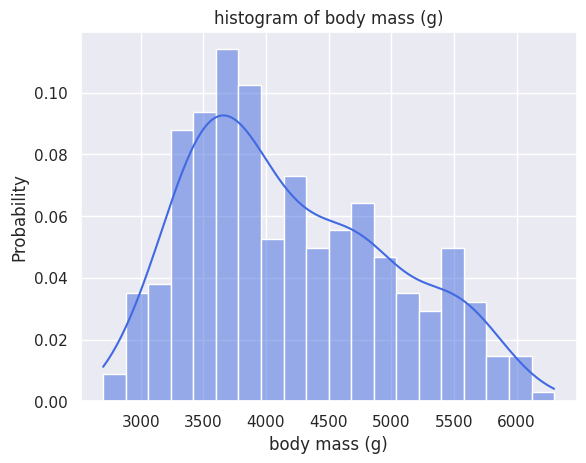

In [6]:
sns.histplot(
    data = df,
    x = "body_mass_g",
    color = "royalblue",
    bins = 20,
    kde = True,
    stat = "probability"
)
plt.xlabel("body mass (g)")
plt.title("histogram of body mass (g)")

<Axes: xlabel='body_mass_g', ylabel='Density'>

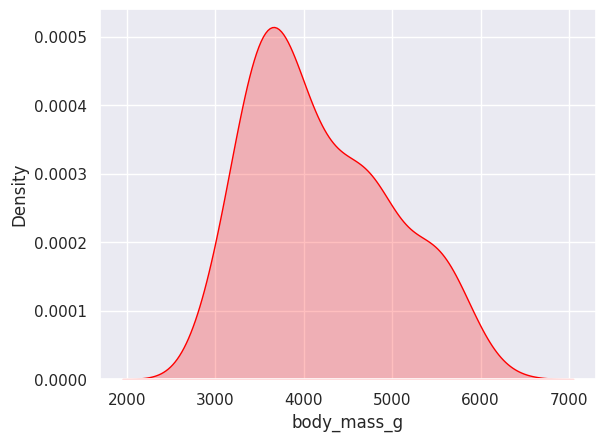

In [7]:
sns.kdeplot(
    data = df,
    x = "body_mass_g",
    fill = True,
    color = "red"
)

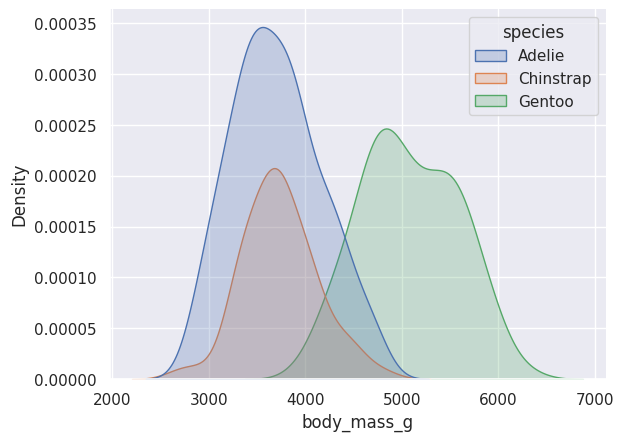

In [8]:
sns.kdeplot(
    data = df,
    x = "body_mass_g",
    hue = "species",
    fill = True
)
sns.despine()

<Axes: xlabel='body_mass_g', ylabel='species'>

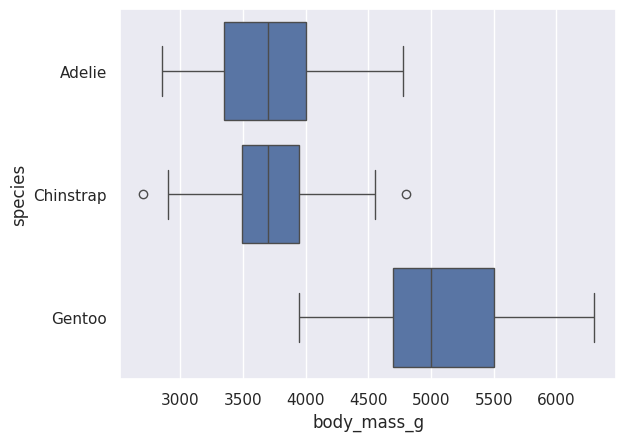

In [9]:
sns.boxplot(
    data = df,
    x = "body_mass_g",
    y = "species"
)

<Axes: xlabel='body_mass_g', ylabel='island'>

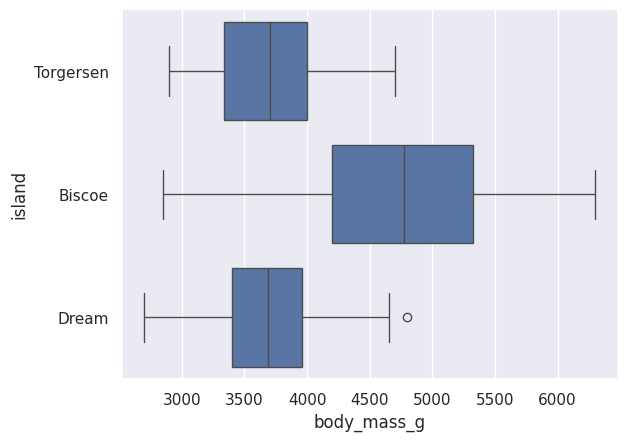

In [10]:
sns.boxplot(
    data = df,
    x = "body_mass_g",
    y = "island"
)

<Axes: xlabel='body_mass_g', ylabel='species'>

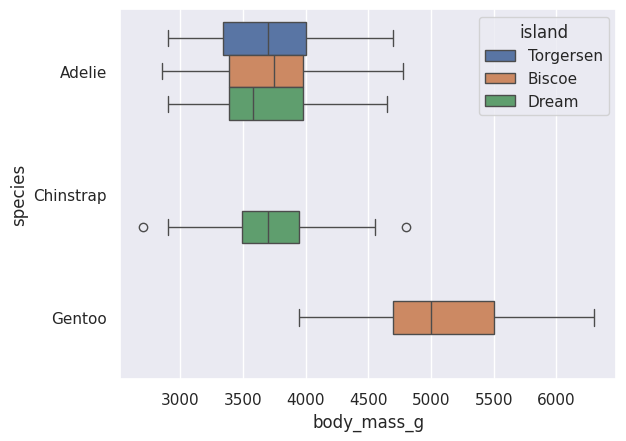

In [11]:
sns.boxplot(
    data = df,
    x = "body_mass_g",
    y = "species",
    hue = "island"
)

<Axes: xlabel='species', ylabel='body_mass_g'>

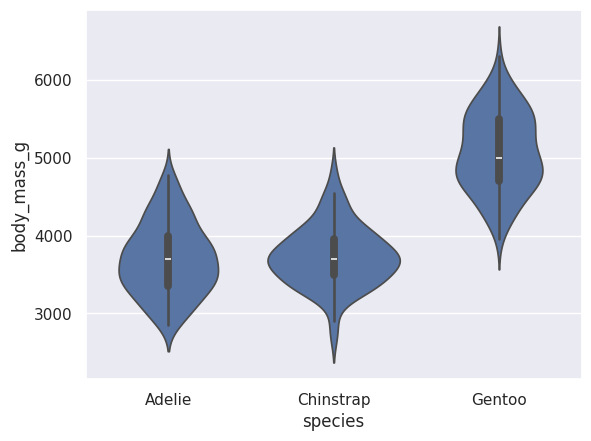

In [12]:
sns.violinplot(data = df, y = "body_mass_g", x = "species")

In [13]:
df.groupby("species")["body_mass_g"].describe()

,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
Adelie,151.0,3700.662252,458.566126,2850.0,3350.0,3700.0,4000.0,4775.0
Chinstrap,68.0,3733.088235,384.335081,2700.0,3487.5,3700.0,3950.0,4800.0
Gentoo,123.0,5076.016260,504.116237,3950.0,4700.0,5000.0,5500.0,6300.0


## Facetgrid

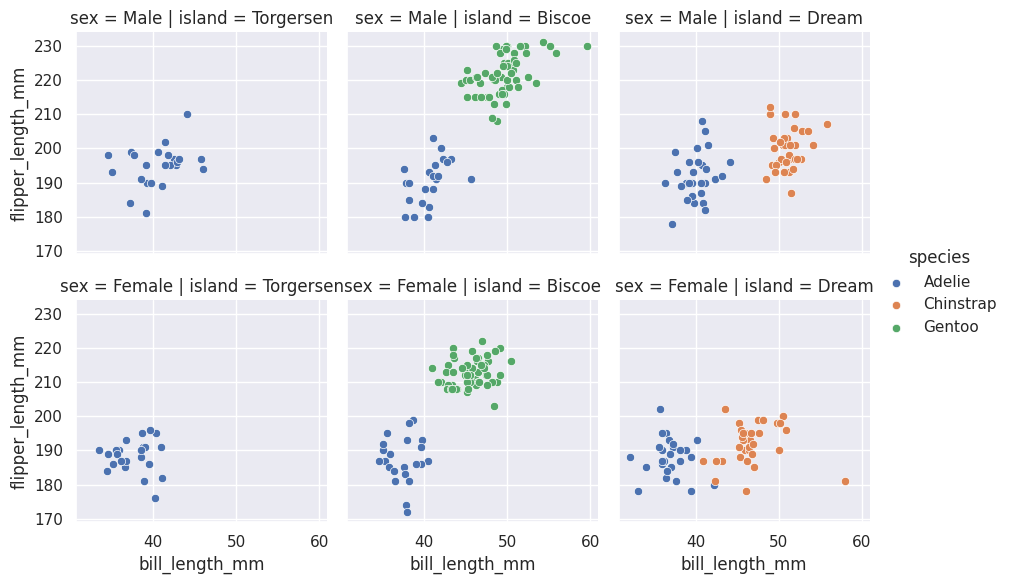

In [14]:
# faceted plot (can facet with respect to row, column and hue)
fig = sns.FacetGrid(df, row = "sex", col  = "island", hue  = "species")
fig.map(sns.scatterplot, "bill_length_mm", "flipper_length_mm").add_legend()

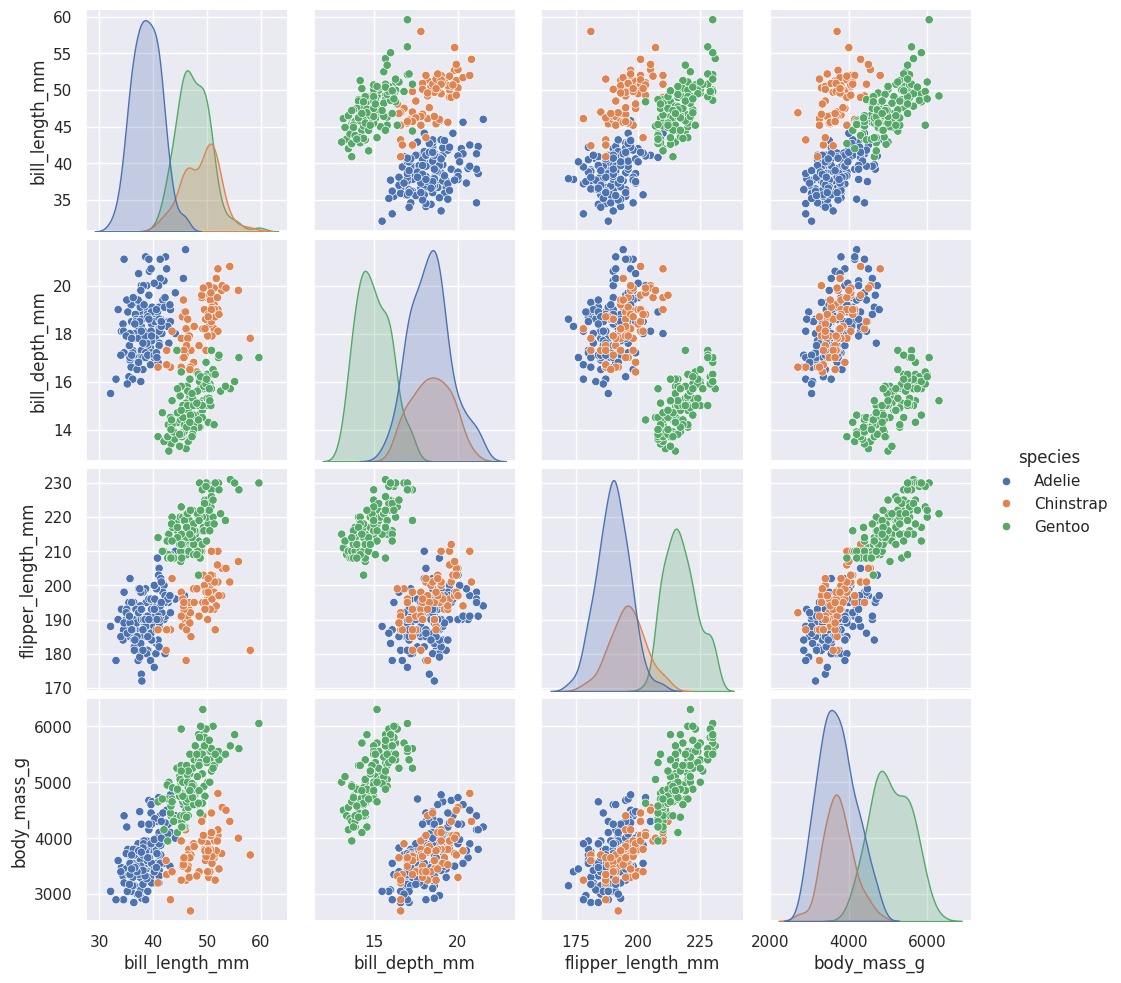

In [15]:
sns.pairplot(df, hue = "species")

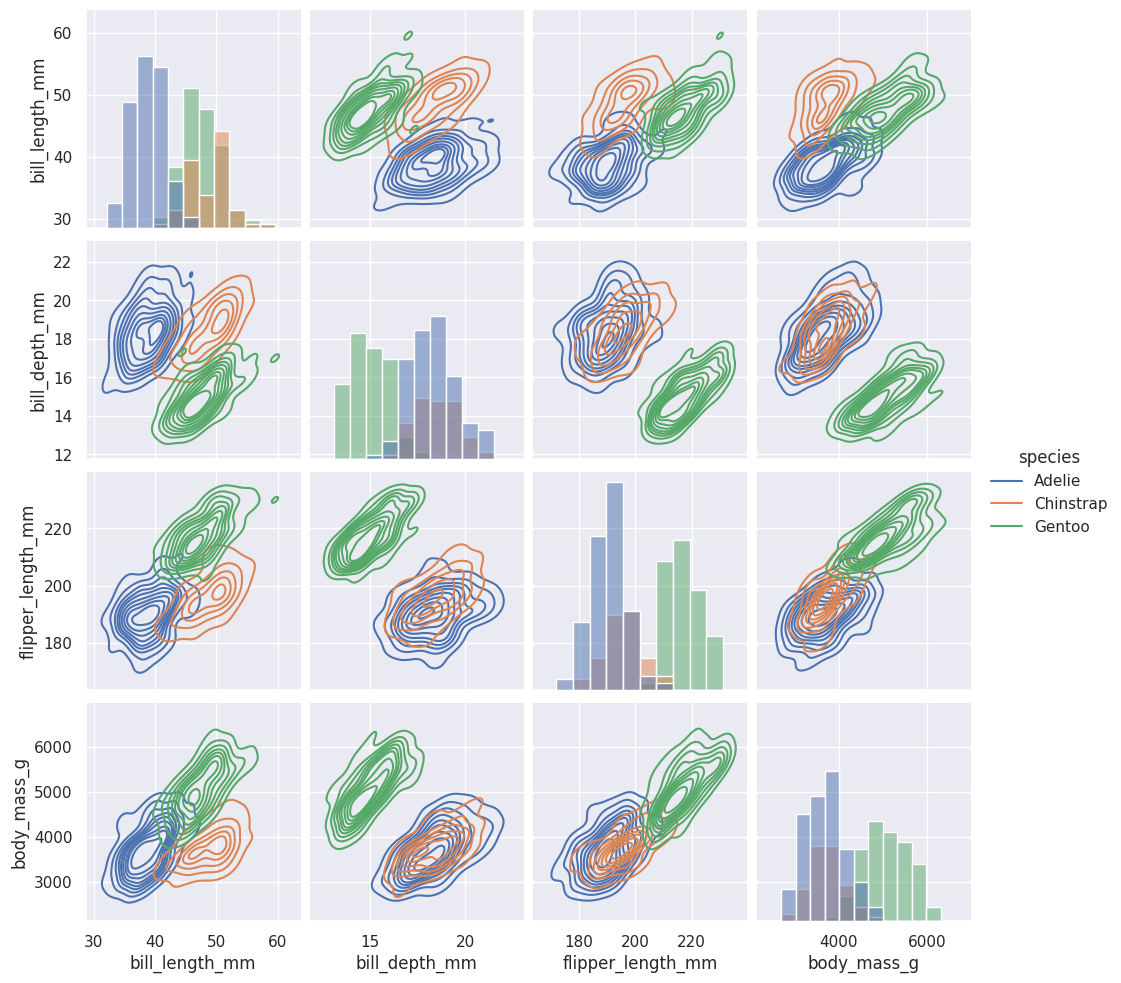

In [16]:
sns.pairplot(df, hue = "species", kind = "kde", diag_kind = "hist")

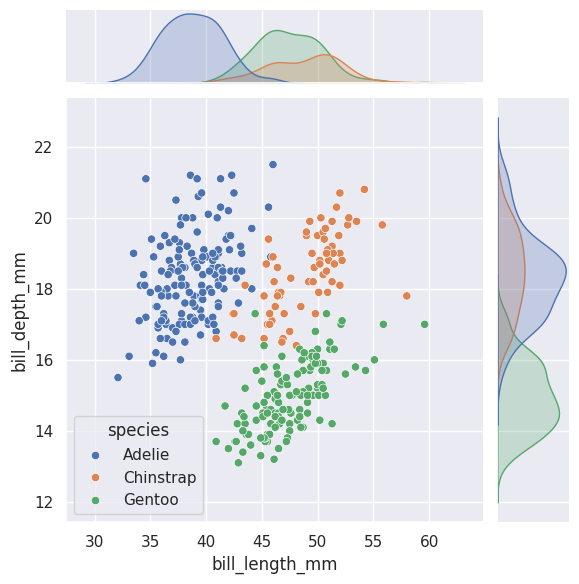

In [17]:
sns.jointplot(data = df, x = "bill_length_mm", y = "bill_depth_mm", hue = "species")

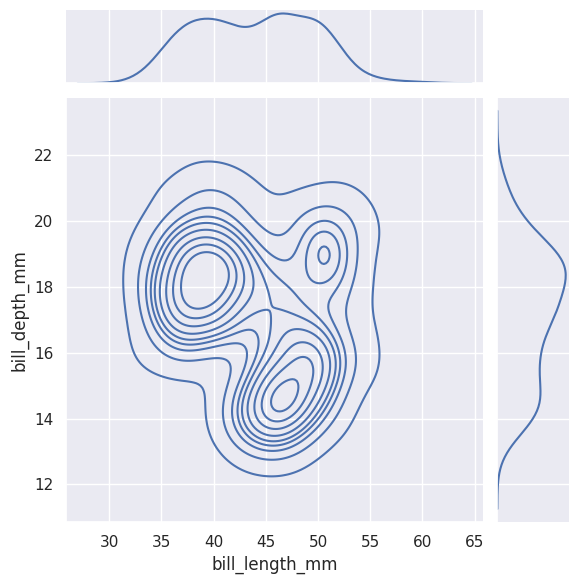

In [18]:
sns.jointplot(data = df, x = "bill_length_mm", y = "bill_depth_mm", kind = "kde")

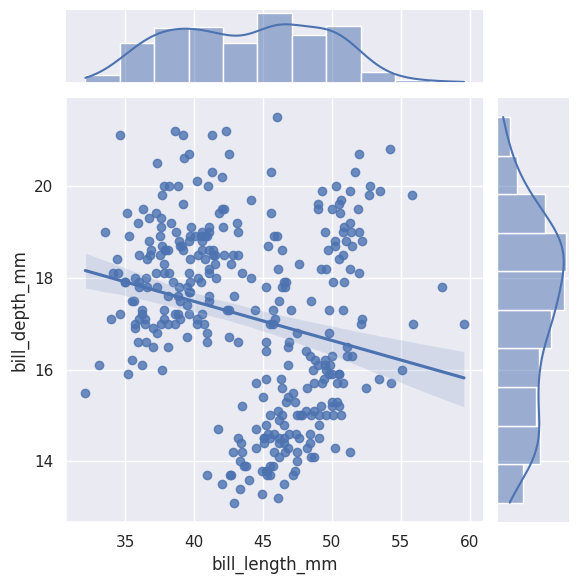

In [19]:
sns.jointplot(data = df, x = "bill_length_mm", y = "bill_depth_mm", kind = "reg")